<a href="https://colab.research.google.com/github/charlesdgburns/ring_attractors_and_rnns/blob/main/Ring_attractors_and_RNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

A recent blogpost by Konrad Kording claims that ["Atrractors are usually not mechanisms"](https://kording.substack.com/p/attractors-are-usually-not-mechanisms?r=ao63f&utm_campaign=post&utm_medium=web&triedRedirect=true).

**TLDR**: (please go read the blogpost, I can't do it justice in 15 lines)

Two words need clarifiation here:
- 'Attractors': referring to a neural network with dynamics such that the activity across all neurons that has stable points or basins of stable points (a mathematical object)
- 'mechanisms': referring to implementations of computation in the brain at the level of synaptic connectivity (a physiological object)

the blogpost supports its main claim by arguing with the head-direction circuit as an example:

1. Head-direction circuits found in brains can be described by 'attractors'
  - These attractors can be designed with specified connectivity (e.g. mexican-hat-like connectivity).

2. There is lacking evidence for 'mechanisms' of these attractors in the brain.
  - No strong evidence of mexican-hat-like connectivity or synaptic interactions accounting for it.

3. 'Non-Attractor Alternative': head-direction circuits exist in RNNs trained to integrate velocity.
  - in other words, attractors are not necessary for head-direction circuit activity.

4. Fitting RNN's to neurons can hallucinate attractors.
 - neural activity derived from a non-attractor mechanism can be described by attractor computations.




---
The blogpost is a great read - it helps us define and clarify what words we use when describing what's going on in our brains. Personally, I agree with points 1 and 2, I hadn't seen point 4 before, and I'm sceptical about point 3.

I don't think the argument that RNN's are 'Non-attractor' is valid.

 Konrad otherwise summarises this part of his argument quite elegantly:**"*The ugly duckling mimics the swan perfectly*"**. Here the *swan* is a simple and elegant head-direction attractor described by interactions between neurons (weights $w_{i,j}$ e.g. from a mexian-hat-like interaction kernel). The *ugly duckling* is an RNN which is trained to mimic a head-direction attractor (optimised to integrate velocity to predict head direction).

Let's take a closer look.

# The ugly duckling is a swan

We all know how the story ends. I've got a feeling that this story ends there too.

## the Swan: a ring attractor from simple interaction kernels.

Here we aim for a small replication of [Noorman et al., 2024](https://www.nature.com/articles/s41593-024-01766-5), demonstrating that small elegantly designed neural networks can maintain head direction information.




/tmp/ipython-input-234-2689979262.py:63: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  w = fsolve(fixed_point_eq, np.pi/2, xtol=1e-12)[0]
/tmp/ipython-input-234-2689979262.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(w_pad = 10, h_pad =0)


Using parameters: JE=2.100, JI=-0.207 (boundary was 0.000)


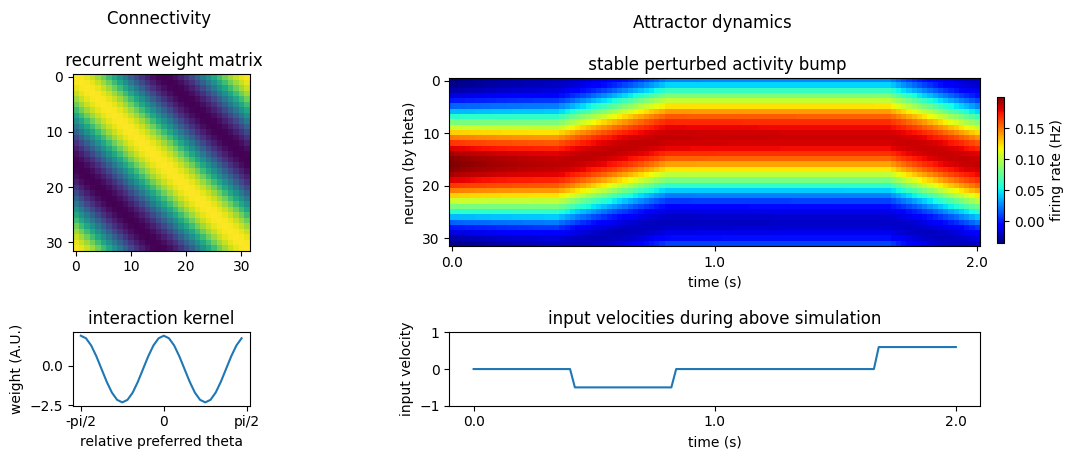

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize

## Functions ##

def simulate_network(W_sym, W_asym, h0, t, dt, theta, c_ff, vin):
    """Simulate network dynamics with exact connectivity"""
    N = len(theta)
    h = np.zeros((len(t), N))
    h[0] = h0
    psi = np.zeros(len(t))
    for i in range(1, len(t)):
        r = np.maximum(0, h[i-1]) # reLU activation
        total_input = (W_sym + vin[i] * W_asym) @ r / N #input defined by velocity and connectivity weights
        h[i] = h[i-1] + dt * (-h[i-1] + total_input + c_ff) / tau #euler update method
        # Compute bump phase
        r_current = np.maximum(0, h[i])
        if np.sum(r_current) > 1e-8:
            psi[i] = np.arctan2(np.sum(np.sin(theta) * r_current),np.sum(np.cos(theta) * r_current)) #
        else:
            psi[i] = psi[i-1]
    return np.unwrap(psi), h

def find_JI_boundary(JE, theta, cf):
    """Find JI boundary using contour method as described in the paper"""
    # Sample bump widths and orientations
    n_samples = 100
    psi_samples = np.linspace(0, 2*np.pi, n_samples, endpoint=False)
    w_samples = np.linspace(2*np.pi/len(theta), 2*(len(theta)-1)*np.pi/len(theta), n_samples)
    min_JI = 0 #for simplicity, consider only networks with negative inhibition
    for psi in psi_samples:
        for w in w_samples:
            # Calculate feven (equation S19)
            feven = np.mean(np.cos(theta - psi) * (np.cos(theta - psi) - np.cos(w/2)))
            # Only consider points on the JE*feven = 1 contour
            if abs(JE * feven - 1) > 1e-6:
                continue
            # Calculate f0 (equation S18)
            f0 = np.mean(np.cos(theta - psi) - np.cos(w/2))
            # Compute JI bound (equation 8)
            JI_candidate = -np.cos(w/2) / f0
            if JI_candidate < min_JI:
                min_JI = JI_candidate
    return min_JI

def find_JI_for_amplitude(JE, theta, cf, A_target, JI_bound):
    """Find JI that produces bump with amplitude ≈ A_target"""
    def objective(JI):
        h = initialize_bump(JE, JI, theta, cf, 0)
        current_amp = np.max(h)
        return (current_amp - A_target)**2
    # Search between reasonable bounds
    res = minimize(objective, x0=JI_bound-1, bounds=[(JI_bound-10, JI_bound+10)])
    return res.x[0]

def initialize_bump(JE, JI, theta, cf, psi0):
    """Initialize exact bump solution using current parameters"""
    # Solve for bump width w that satisfies fixed point condition
    def fixed_point_eq(w):
        feven = np.mean(np.cos(theta - psi0) * (np.cos(theta - psi0) - np.cos(w/2)))
        return JE * feven - 1
    w = fsolve(fixed_point_eq, np.pi/2, xtol=1e-12)[0]
    # Calculate bump profile
    f0 = np.mean(np.cos(theta - psi0) - np.cos(w/2))
    rho0 = -cf / (2 * (np.cos(w/2) + JI * f0))
    h = 2 * rho0 * (np.cos(theta - psi0) - np.cos(w/2))
    return h

## Example ##

# PARAMETERS #
N = 32                # Number of neurons
tau = 0.1             # Time constant (s)
c_ff = 0.1            # constant Feedforward input (example value > 0)
A_target = 0.2        # Target bump amplitude
JE = 2.1              # Local excitation (example value > 2)
dt = 0.02             # refresh rate in seconds (0.02~50Hz)
tmax = 2              # duration of simulation in seconds

# Neurons organised by preferred headings (evenly spaced)
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
dtheta = theta[1] - theta[0]

# Finding JI which gives stable attractor dynamics is slightly tricky;
# we follow the methods in the paper
JI_bound = find_JI_boundary(JE, theta, c_ff)
JI = find_JI_for_amplitude(JE, theta, c_ff, A_target, JI_bound)
print(f"Using parameters: JE={JE:.3f}, JI={JI:.3f} (boundary was {JI_bound:.3f})")
# ! Now we can create connectivity matrices
W_sym = JI + JE * np.cos(theta[:,None] - theta[None,:])
W_asym = np.sin(theta[:,None] - theta[None,:])
# note: we can describe W_sym as an interaction between neurons of a given preferred orientation.
interaction_kernel = [W_sym[-x][x] for x in range(len(W_sym))]
# Initialize exact bump at 0 degree heading direction
h0 = initialize_bump(JE, JI, theta, c_ff, psi0=0)
# input velocities need to be given for each timestep in the simulation.
t = np.arange(0, tmax+dt, dt)
v_tile = [0,-0.5,0,0,0.6] #evenly tiles timesteps with velocities in list
input_velocities =  np.concat([np.tile(np.array(v_tile),
                                (int(np.ceil(len(t)/len(v_tile))),1))[:,i]
                               for i in range(len(v_tile))])
psi, h = simulate_network(W_sym, W_asym, h0, t, dt, theta, c_ff, vin=input_velocities)#

## Plotting ##
fig, ax = plt.subplots(2,2, figsize = (10,5),
                       width_ratios=(1,3), height_ratios=(1,1/5))
ax[0][0].set(title='Connectivity \n \n recurrent weight matrix')
ax[0][0].imshow(W_sym)

ax[1][0].set(title='interaction kernel',
             ylabel = 'weight (A.U.)',
             xlabel = 'relative preferred theta')
ax[1][0].plot(interaction_kernel)
ax[1][0].set_xticks([0,int(N/2),N],labels = ['-pi/2', 0,'pi/2'])


ax[0][1].set(title='Attractor dynamics \n \n stable perturbed activity bump',
             ylabel = 'neuron (by theta)',
             xlabel = 'time (s)')
ax[0][1].set_xticks([0, len(t)//2, len(t)-1], labels = t[[0,len(t)//2,-1]] )
bump_map = ax[0][1].imshow(h.T, cmap = 'jet')
fig.colorbar(bump_map,ax=ax[0][:], location='right', anchor = (2,0.5), shrink = 0.5, label = 'firing rate (Hz)')

ax[1][1].set(title='input velocities during above simulation',
             xlabel = 'time (s)',
             ylabel = 'input velocity',
             ylim = (-1,1))
ax[1][1].set_xticks([0, len(t)//2, len(t)-1], labels = t[[0,len(t)//2,-1]] )
ax[1][1].plot(input_velocities[:(len(t))])
fig.tight_layout(w_pad = 10, h_pad =0)

**Figure 1**: a simple network which balances global inhibition $J_I$ and a local excitatory excitation $J_E$ can achieve stable continuous attractor dynamics given velocity inputs.

The dynamics are goverened by:

In the weight matrix

In [ ]:

import ipywidgets as widgets
import matplotlib as mpl

def update_plot(v_input, time_step):
    """Updates the plot with a new velocity input."""
    global current_vin # Use a global variable to store the current velocity input
    current_vin = -v_input # Update the global variable. flip sign so positive is clockwise and negative ccw
    psi, h = simulate_network(W_sym, W_asym, h0, t, dt, theta, c_ff, vin=np.repeat(current_vin, len(t)))
    plt.clf() #clear previous plot
    ax = plt.subplot(111, projection='polar')
    # Set the color map
    norm = mpl.colors.Normalize(vmin=0, vmax=A_target)
    cmap = mpl.cm.viridis
    # Plot the neurons as colored points on the circle
    ax.scatter(theta, np.ones_like(theta), c=h[time_step], cmap=cmap, norm=norm, s=100, edgecolors='k')
    ax.axis('off')
    # Add a colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, label='Activity', ax=ax, shrink=0.7)

    plt.show()

# Display the interactive plot
widgets.interact(update_plot,v_input=(-1,1,0.1), time_step=widgets.Play(min=0,max=len(t)-1,disabled=False));
# You'll have to hit play to watch the animation - in google colab this play button is sometimes hidden but still functional.
# (it's placed lower left of the 'v_input' label)


## the Ugly Duckling: an RNN trained to integrate velocity to predict head direction